# ECG Arrhythmia Classification
Loads preprocessed beats, trains a stacked LSTM, and evaluates on the held-out test set.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Configuration

In [2]:
BEATS_FILE = 'data/beats.npz'
MODEL_FILE = 'data/ecg_lstm.pt'
SEED       = 0
BATCH_SIZE = 128
EPOCHS     = 60
LR         = 1e-3
PATIENCE   = 8

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## Dataset

In [3]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, 250) -> unsqueeze to (N, 250, 1) for LSTM input
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Load & Split Data

In [4]:
raw     = np.load(BEATS_FILE)
X, y    = raw['X'], raw['y']
classes = raw['classes']

dataset = ECGDataset(X, y)
n       = len(dataset)
n_test  = int(0.15 * n)
n_val   = int(0.15 * n)
n_train = n - n_test - n_val

generator = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=generator)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE)

print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')
print(f'Classes: {classes}')

Train: 78793 | Val: 16884 | Test: 16884
Classes: ['F' 'N' 'Q' 'S' 'V']


## Model Definition

In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, n_classes, dropout=0.3):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.bn1   = nn.BatchNorm1d(hidden1)

        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.bn2   = nn.BatchNorm1d(hidden2)

        self.head = nn.Sequential(
            nn.Linear(hidden2, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop1(out)
        out = self.bn1(out.transpose(1, 2)).transpose(1, 2)

        out, _ = self.lstm2(out)
        out = out[:, -1, :]
        out = self.drop2(out)
        out = self.bn2(out)

        return self.head(out)


model = ECGClassifier(input_size=1, hidden1=128, hidden2=64, n_classes=len(classes)).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

ECGClassifier(
  (lstm1): LSTM(1, 128, batch_first=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm2): LSTM(128, 64, batch_first=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)

Trainable parameters: 121,605


## Loss, Optimiser & Scheduler

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=4)

## Training Loop

In [ ]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)
        correct      += (logits.argmax(1) == yb).sum().item()
        total        += len(xb)
    t_loss = running_loss / total
    t_acc  = correct / total

    # Validate
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            loss    = criterion(logits, yb)
            running_loss += loss.item() * len(xb)
            correct      += (logits.argmax(1) == yb).sum().item()
            total        += len(xb)
    v_loss = running_loss / total
    v_acc  = correct / total

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);   val_accs.append(v_acc)
    scheduler.step(v_loss)

    # Early stopping
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), MODEL_FILE)
        patience_counter = 0
    else:
        patience_counter += 1

    print(f'Epoch {epoch:3d} | '
        f'train loss {t_loss:.4f} acc {t_acc:.4f} | '
        f'val loss {v_loss:.4f} acc {v_acc:.4f}')


    if patience_counter >= PATIENCE:
        print(f'Early stopping triggered at epoch {epoch}.')
        break

print(f'\nBest model saved -> {MODEL_FILE}')

Epoch   1 | train loss 0.2579 acc 0.9329 | val loss 0.2111 acc 0.9427
Epoch   2 | train loss 0.2266 acc 0.9397 | val loss 0.1993 acc 0.9427
Epoch   3 | train loss 0.1999 acc 0.9471 | val loss 0.1586 acc 0.9559
Epoch   4 | train loss 0.1825 acc 0.9521 | val loss 0.1621 acc 0.9545
Epoch   5 | train loss 0.1801 acc 0.9526 | val loss 0.1574 acc 0.9566
Epoch   6 | train loss 0.1660 acc 0.9568 | val loss 0.1547 acc 0.9571
Epoch   7 | train loss 0.1565 acc 0.9588 | val loss 0.1400 acc 0.9626
Epoch   8 | train loss 0.1434 acc 0.9622 | val loss 0.1311 acc 0.9643
Epoch   9 | train loss 0.1402 acc 0.9626 | val loss 0.1178 acc 0.9681
Epoch  10 | train loss 0.1300 acc 0.9655 | val loss 0.1269 acc 0.9652
Epoch  11 | train loss 0.1222 acc 0.9675 | val loss 0.1155 acc 0.9677
Epoch  12 | train loss 0.1168 acc 0.9692 | val loss 0.1054 acc 0.9712
Epoch  13 | train loss 0.1126 acc 0.9692 | val loss 0.1158 acc 0.9669
Epoch  14 | train loss 0.1147 acc 0.9685 | val loss 0.1064 acc 0.9703
Epoch  15 | train lo

## Training Curves

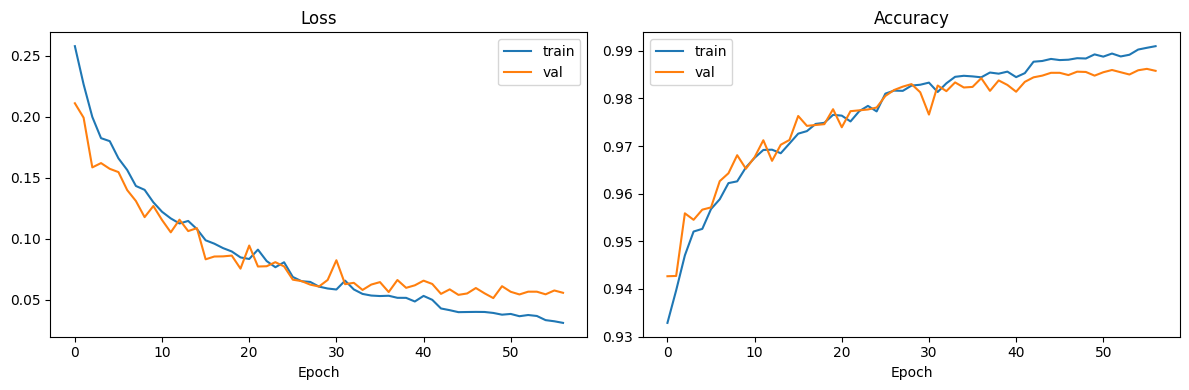

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='train')
axes[0].plot(val_losses,   label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(train_accs, label='train')
axes[1].plot(val_accs,   label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/training_curves.png', dpi=100)
plt.show()

## Evaluate on Test Set

In [11]:
model.load_state_dict(torch.load(MODEL_FILE, map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print(classification_report(all_true, all_preds, target_names=classes))

              precision    recall  f1-score   support

           F       0.84      0.80      0.82       123
           N       0.99      0.99      0.99     13631
           Q       0.98      0.98      0.98      1666
           S       0.90      0.82      0.86       375
           V       0.97      0.97      0.97      1089

    accuracy                           0.99     16884
   macro avg       0.94      0.92      0.93     16884
weighted avg       0.99      0.99      0.99     16884



## Confusion Matrix

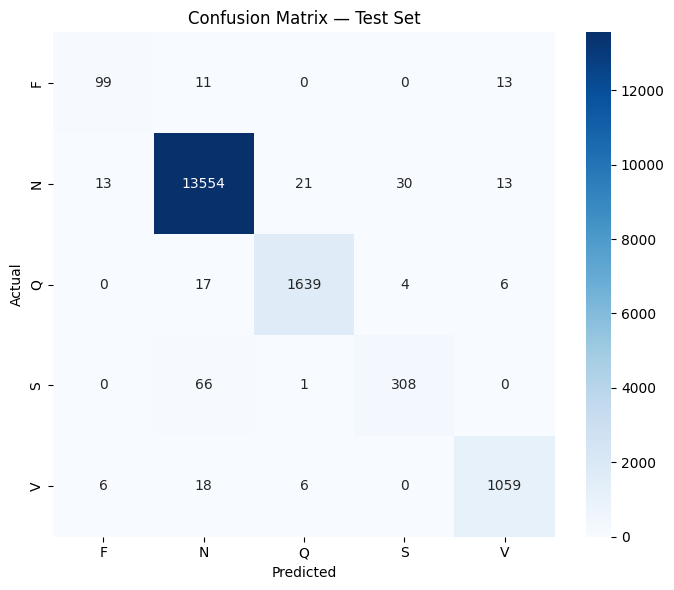

In [ ]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('data/confusion_matrix.png', dpi=100)
plt.show()